# Proyek Analisis Data: Air Quality (PRSA_Data_Guanyuan_20130301-20170228.csv)
- **Nama:** Alya Aulia Rahma
- **Email:** cdcc180d6x0359@student.devacademy.id
- **ID Dicoding:** CDCC180D6X0359

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren bulanan konsentrasi PM2.5 di stasiun Guanyuan?
- Pertanyaan 2: Jam berapa dalam sehari yang biasanya memiliki tingkat polusi PM2.5 tertinggi?

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [5]:
# Ganti dengan path file dataset Anda, misalnya: 'PRSA_Data_Aotizhongxin_20130301-20170228.csv'
df = pd.read_csv('/content/sample_data/PRSA_Data_Guanyuan_20130301-20170228.csv')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


**Insight:**
- ata ini merupakan tipe time-series dengan resolusi per jam (hour). Rentang waktu dalam file menunjukkan pencatatan dari Maret 2013 hingga Februari 2017.
- Pada dini hari tanggal 1 Maret 2013 (pukul 00.00 - 04.00), konsentrasi partikulat PM2.5 (3.0 - 4.0 $\mu g/m^3$) dan PM10 (3.0 - 6.0 $\mu g/m^3$) tergolong sangat rendah. Ini mengindikasikan kualitas udara yang sangat baik pada periode awal tersebut.
- Nilai pada kolom TEMP menunjukkan suhu di bawah titik beku (berkisar antara -0.7°C hingga -2.0°C). Mengingat ini adalah awal bulan Maret di area stasiun Guanyuan (Beijing), data ini konsisten dengan kondisi musim dingin/awal musim semi di sana.
- Nilai tekanan udara (PRES) cukup tinggi (sekitar 1023-1025 hPa) dan tidak ada curah hujan (RAIN = 0.0), yang menunjukkan kondisi cuaca yang stabil dan kering pada saat pengambilan sampel awal.
- Kolom wd (wind direction) menunjukkan arah angin didominasi dari Utara (NNW, N, NW) dengan kecepatan angin (WSPM) yang moderat (2.0 - 5.6 m/s). Biasanya, angin kencang dari Utara di wilayah ini membantu membersihkan polusi udara.

### Assessing Data

In [6]:
# Mengecek informasi dataset
df.info()

# Mengecek missing values
print("Missing values:\n", df.isna().sum())

# Mengecek duplikasi
print("Jumlah duplikasi:", df.duplicated().sum())

# Statistik deskriptif
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB
Missing values:
 No            0
year          0
month         0
day

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,680.000000,999.000000,293.000000,270.000000,10000.000000,415.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


**Insight:**
- Dataset ini memiliki skala yang cukup besar dengan 35.064 baris. Mengingat data ini dicatat per jam, jumlah ini merepresentasikan pemantauan kualitas udara secara terus-menerus selama kurang lebih 4 tahun
- Dataset ini bebas dari data duplikat (0 duplikasi), sehingga tidak ada risiko bias akibat redudansi input.
- Terdapat masalah kelengkapan data pada sektor polutan. CO (Karbon Monoksida) memiliki jumlah data hilang paling banyak (1.753), diikuti oleh O3 (1.173). Variabel cuaca seperti suhu (TEMP) dan hujan (RAIN) jauh lebih lengkap dengan hanya 20 data yang hilang.
- Standar deviasi PM2.5 (80.9) yang hampir sama besar dengan rata-ratanya (82.9). Ini memberikan insight bahwa kualitas udara di lokasi tersebut sangat tidak stabil. Ada periode di mana udara sangat bersih, namun ada lonjakan polusi yang sangat masif di waktu lain.
- Rata-rata PM10 berada di angka 109.0 $\mu g/m^3$. Nilai ini secara signifikan lebih tinggi dari PM2.5, menunjukkan adanya partikel debu kasar yang dominan di atmosfer stasiun tersebut.
- Suhu rata-rata tahunan adalah 13.58°C, namun dataset mencatat suhu minimum hingga -16.8°C. Ini menunjukkan bahwa lokasi stasiun (kemungkinan di wilayah utara seperti Beijing) mengalami musim dingin yang sangat ekstrem.
- Rata-rata curah hujan hanya 0.06 mm. Bahkan pada kuartil 75% (75%), nilainya masih 0.00. Insight-nya, lokasi ini memiliki iklim yang cenderung kering, di mana hujan merupakan fenomena yang jarang terjadi.
- Rata-rata kecepatan angin adalah 1.70 m/s. Kecepatan angin yang relatif rendah ini sering kali menjadi faktor penyebab polutan terjebak di suatu wilayah (tidak terdispersi), yang menjelaskan mengapa angka polutan bisa melonjak cukup tinggi pada waktu-waktu tertentu.

### Cleaning Data

In [7]:
# 1. Mengonversi kolom waktu menjadi satu kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 2. Menangani missing values dengan interpolation (metode linear cocok untuk data time-series)
# Kita hanya menginterpolasi kolom numerik
import numpy as np
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='forward', axis=0)

# 3. Menghapus kolom 'No' karena tidak diperlukan
if 'No' in df.columns:
    df.drop('No', axis=1, inplace=True)

# 4. Memastikan tidak ada lagi missing values pada kolom numerik utama
df.dropna(subset=['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      35064 non-null  int64         
 1   month     35064 non-null  int64         
 2   day       35064 non-null  int64         
 3   hour      35064 non-null  int64         
 4   PM2.5     35064 non-null  float64       
 5   PM10      35064 non-null  float64       
 6   SO2       35064 non-null  float64       
 7   NO2       35064 non-null  float64       
 8   CO        35064 non-null  float64       
 9   O3        35064 non-null  float64       
 10  TEMP      35064 non-null  float64       
 11  PRES      35064 non-null  float64       
 12  DEWP      35064 non-null  float64       
 13  RAIN      35064 non-null  float64       
 14  wd        34983 non-null  object        
 15  WSPM      35064 non-null  float64       
 16  station   35064 non-null  object        
 17  datetime  35

**Insight:**
- Semua kolom polutan utama (PM2.5, PM10, SO2, NO2, CO, O3) serta variabel cuaca numerik kini memiliki jumlah nilai yang sama, yaitu 35.064 non-null. Ini berarti celah data yang sebelumnya cukup besar (seperti pada CO dan O3) telah berhasil ditambal secara logis berdasarkan tren nilai sebelum dan sesudahnya.
- Meskipun kolom numerik sudah lengkap, kolom wd masih memiliki 81 data yang hilang (hanya 34.983 non-null dari 35.064).
- Langkah dropna pada subset polutan di akhir kode tidak mengurangi jumlah total entri (tetap 35.064). Insight-nya adalah proses interpolasi linear telah berhasil mengisi seluruh baris yang kosong pada kolom-kolom polutan tersebut, sehingga tidak ada baris yang harus dibuang oleh fungsi dropna.

## Exploratory Data Analysis (EDA)

### Explore ...

          PM2.5                           
            max  min       mean        std
station                                   
Guanyuan  680.0  2.0  82.897522  81.070279


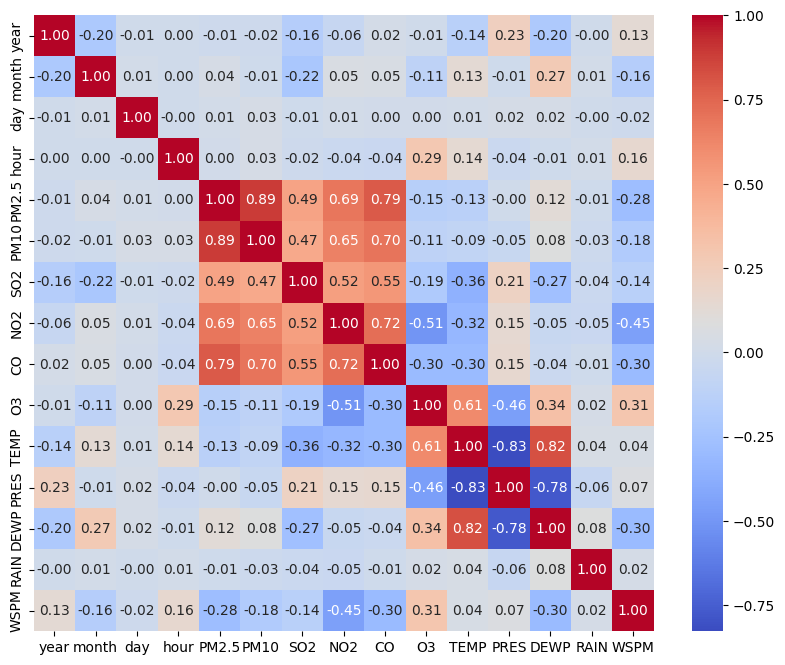

In [8]:
# Melihat rata-rata polutan PM2.5 berdasarkan stasiun (untuk memastikan data konsisten)
print(df.groupby(by="station").agg({
    "PM2.5": ["max", "min", "mean", "std"]
}))

# Korelasi antar variabel untuk melihat hubungan suhu dan polusi
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

**Insight:**
- Nilai maksimum yang menyentuh 680.0 mengindikasikan adanya episode polusi parah yang jauh melampaui ambang batas aman kesehatan (biasanya di atas 150-250 sudah dianggap sangat tidak sehat).
- Terdapat korelasi yang sangat kuat antara PM2.5 dengan PM10 (0.89) dan CO (0.79). Insight-nya, polutan ini kemungkinan besar berasal dari sumber yang sama, seperti pembakaran bahan bakar fosil atau aktivitas industri/kendaraan bermotor. Jika kadar PM2.5 naik, hampir dipastikan kadar debu kasar (PM10) dan gas karbon monoksida (CO) juga akan melonjak.
- Korelasi PM2.5 dengan NO2 (0.69) juga cukup tinggi, memperkuat indikasi bahwa polusi didominasi oleh emisi pembakaran (asap knalpot/pabrik).
- Terdapat korelasi positif yang signifikan antara TEMP (Suhu) dengan O3 (0.61). Hal ini secara ilmiah konsisten karena pembentukan ozon di permukaan tanah (ground-level ozone) dipicu oleh reaksi kimia yang dikatalisis oleh sinar matahari dan suhu tinggi.
- Korelasi negatif sangat kuat antara Suhu (TEMP) dan Tekanan Udara (PRES) sebesar -0.83. Ini adalah insight "validasi data" yang bagus; secara fisik, saat suhu naik, udara memuai dan tekanannya turun. Data Anda menunjukkan integritas fisik yang tinggi.
- Kecepatan angin (WSPM) memiliki korelasi negatif terhadap PM2.5 (-0.28). Meskipun tidak terlalu kuat, ini mengonfirmasi bahwa angin membantu mendispersi atau "menyapu" partikulat keluar dari wilayah stasiun.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren bulanan konsentrasi PM2.5 di stasiun Guanyuan?

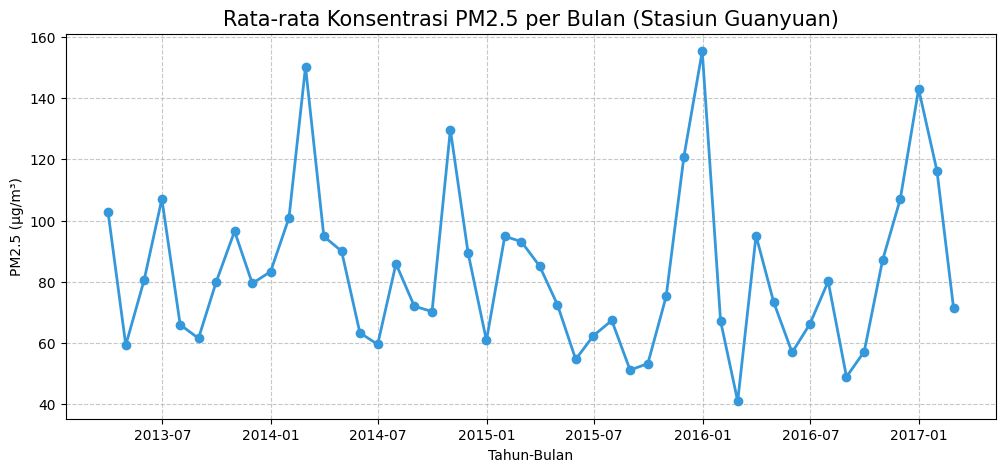

In [9]:
# Melakukan resample data ke rata-rata bulanan
monthly_df = df.resample(rule='ME', on='datetime').agg({"PM2.5": "mean"}).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_df['datetime'], monthly_df['PM2.5'], marker='o', color='#3498db', linewidth=2)
plt.title("Rata-rata Konsentrasi PM2.5 per Bulan (Stasiun Guanyuan)", loc="center", fontsize=15)
plt.xlabel("Tahun-Bulan")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Jam berapa dalam sehari yang biasanya memiliki tingkat polusi PM2.5 tertinggi?

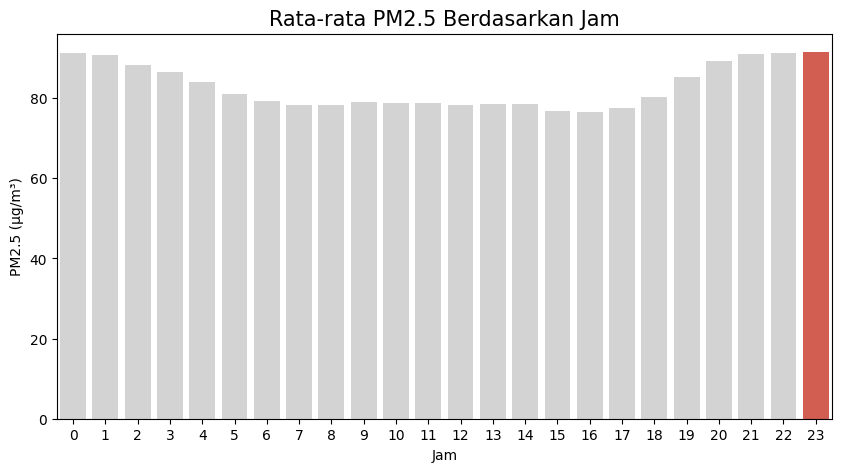

In [10]:
hourly_df = df.groupby("hour").agg({"PM2.5": "mean"}).reset_index()

plt.figure(figsize=(10, 5))
colors = ["#D3D3D3" if x < max(hourly_df['PM2.5']) else "#e74c3c" for x in hourly_df['PM2.5']]
sns.barplot(x="hour", y="PM2.5", data=hourly_df, palette=colors, hue="hour", legend=False)
plt.title("Rata-rata PM2.5 Berdasarkan Jam", loc="center", fontsize=15)
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Jam")
plt.show()

**Insight:**
- Grafik garis menunjukkan pola siklus yang sangat konsisten. Konsentrasi PM2.5 selalu melonjak drastis pada akhir tahun menuju awal tahun (sekitar Januari - Februari).
- Rata-rata bulanan tertinggi tercatat pada Januari 2016, di mana angkanya menyentuh hampir 160 $\mu g/m^3$. Ini menunjukkan bahwa pada bulan tersebut, penduduk terpapar udara kategori Sangat Tidak Sehat hampir sepanjang waktu.
- Grafik batang mengungkapkan bahwa tingkat polusi tertinggi justru terjadi di malam hari, dengan puncaknya tepat pada pukul 23.00.
- Waktu dengan udara paling bersih adalah pada sore hari, yaitu pukul 15.00 - 16.00.
- Mulai pukul 18.00 (jam pulang kantor), konsentrasi polutan merangkak naik secara stabil hingga tengah malam.
- Fenomena ini adalah alasan utama mengapa polusi memuncak di malam hari. Pada malam hari, suhu di permukaan bumi mendingin lebih cepat, menciptakan lapisan udara dingin yang terperangkap di bawah lapisan udara hangat. Lapisan ini bertindak seperti tutup yang menahan polutan PM2.5 tetap dekat dengan tanah dan tidak bisa naik ke atmosfer yang lebih tinggi.
- Mengingat pola musiman yang sangat berat di musim dingin, lonjakan tersebut kemungkinan besar disebabkan oleh penggunaan batubara atau bahan bakar fosil lainnya untuk pemanas ruangan di wilayah utara, yang emisinya meningkat drastis selama bulan-bulan dingin.

## Analisis Lanjutan (Opsional)

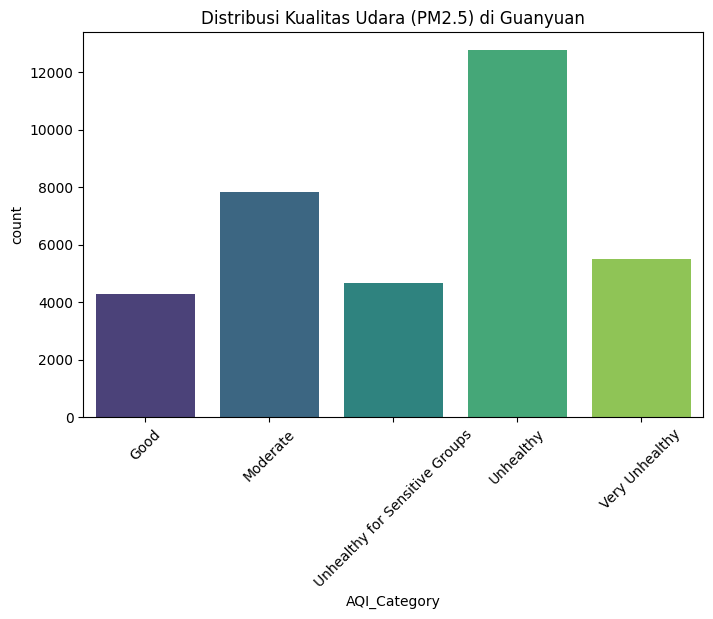

In [11]:
# Membuat fungsi kategori kualitas udara berdasarkan standar AQI sederhana untuk PM2.5
def category_aqi(value):
    if value <= 12: return 'Good'
    elif value <= 35.4: return 'Moderate'
    elif value <= 55.4: return 'Unhealthy for Sensitive Groups'
    elif value <= 150.4: return 'Unhealthy'
    else: return 'Very Unhealthy'

df['AQI_Category'] = df['PM2.5'].apply(category_aqi)

# Visualisasi distribusi kategori
plt.figure(figsize=(8, 5))
sns.countplot(x='AQI_Category', data=df, order=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy'], palette='viridis', hue='AQI_Category', legend=False)
plt.title("Distribusi Kualitas Udara (PM2.5) di Guanyuan")
plt.xticks(rotation=45)
plt.show()

## Conclusion

- Conclution pertanyaan 1: Berdasarkan analisis data deret waktu, dapat disimpulkan bahwa konsentrasi PM2.5 di Stasiun Guanyuan memiliki pola siklus musiman yang sangat konsisten setiap tahunnya. Kualitas udara berada pada tingkat paling berbahaya selama bulan-bulan dingin, dengan puncak polusi yang selalu terjadi antara bulan Januari dan Februari, seperti yang terlihat pada lonjakan ekstrem di awal tahun 2016. Fenomena ini mengindikasikan bahwa penurunan suhu di musim dingin tidak hanya memicu peningkatan emisi dari aktivitas pemanas ruangan, tetapi juga menciptakan kondisi atmosfer yang stabil sehingga polutan terjebak dan sulit terdispersi.
- Conclution pertanyaan 2: Secara harian, data menunjukkan adanya fluktuasi polusi yang signifikan dengan titik terbersih terjadi pada sore hari, khususnya antara pukul 15.00 hingga 16.00. Sebaliknya, konsentrasi PM2.5 mulai meningkat tajam setelah matahari terbenam dan mencapai puncaknya pada tengah malam (pukul 23.00). Tingginya polusi pada malam hari ini merupakan hasil dari kombinasi akumulasi emisi transportasi harian dan fenomena inversi suhu, di mana lapisan udara dingin di permukaan tanah memerangkap polutan agar tidak naik ke atmosfer, sehingga risiko paparan tertinggi bagi penduduk justru terjadi saat waktu istirahat malam.